In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load dataset
df = pd.read_csv(r'reviews.csv')
df = df.iloc[:100]  # Take only the first 20,000 rows

In [9]:
# Label Encoding: Categorize star ratings into Positive, Neutral, and Negative
def categorize_stars(stars):
    if stars >= 4:
        return "Positive"
    elif stars == 3:
        return "Neutral"
    else:
        return "Negative"
    
df["label"] = df["stars"].apply(categorize_stars)

In [10]:
df

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,label
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive
...,...,...,...,...,...,...,...,...,...,...
95,QS7CuOtFLuS3dnwKHRtSYQ,PBnEwGVCBL0N-bET6ZI6kQ,m5-FtgWRd4qA7j0vaOXiXQ,5,0,0,0,Had to wait until my third trip to NOLA to act...,2016-11-10 20:56:13,Positive
96,4PHFo_GRG4FEk1q4X7xQVQ,jbsCBG0A-3wVDjrKar-0Wg,X63jIMRHYBvKKQDuJTRiQQ,5,2,0,1,A GREAT EXPERIENCE!!!!!!!!! I was a completel...,2014-10-11 13:55:05,Positive
97,1c6sgLe07HAhipebsQ1wgA,ZRXvbrutBBULaFS6T9NCwA,HnhxO2cpa15AHI1456Pl6Q,5,0,1,0,Wow! I never thought my sons phone could be re...,2015-10-17 00:55:35,Positive
98,PPgbLBvi34A6m7bKJfTwhw,3TL6HZ1JrKcNTvGDWKlrow,GyC36Pn0Q1-qHnqXys6yFg,1,0,0,0,Service and management terrible... After messi...,2013-12-07 13:17:13,Negative


In [11]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"])

In [12]:
# Optimize CountVectorizer for faster training
# Reduce max_features to limit vocabulary size and exclude rare/common terms
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=1000, min_df=5, max_df=0.95)

In [13]:
# Create SVM pipeline with optimized vectorizer
pipeline = Pipeline([
    ("vectorizer", vectorizer),  # Unigram + Bigram with limited vocabulary
    ("svm", SVC(kernel="linear", probability=True))  # SVM with linear kernel
])

In [14]:
# Parameter tuning with GridSearchCV
param_grid = {
    "svm__C": [0.1, 1, 10],  # Regularization parameter tuning
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vectorizer',
                                        CountVectorizer(max_df=0.95,
                                                        max_features=1000,
                                                        min_df=5,
                                                        ngram_range=(1, 2))),
                                       ('svm',
                                        SVC(kernel='linear',
                                            probability=True))]),
             n_jobs=-1, param_grid={'svm__C': [0.1, 1, 10]}, scoring='accuracy',
             verbose=2)

In [16]:
# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'svm__C': 1}


In [17]:
# Train the model with best parameters
best_model = grid_search.best_estimator_

In [18]:

# Predict on the test set
y_pred = best_model.predict(X_test)

In [19]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7000
Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.33      0.40         3
     Neutral       0.00      0.00      0.00         2
    Positive       0.81      0.87      0.84        15

    accuracy                           0.70        20
   macro avg       0.44      0.40      0.41        20
weighted avg       0.68      0.70      0.69        20



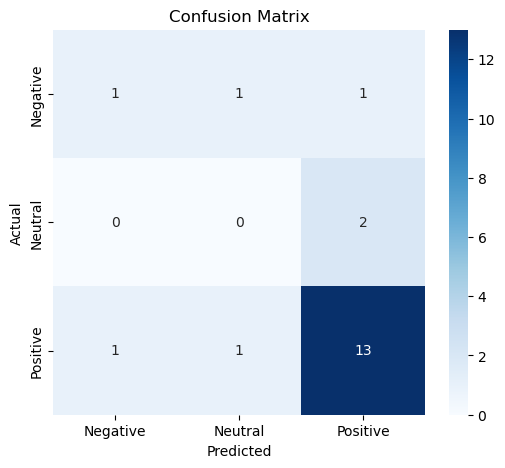

Cross-Validation Accuracy Scores: [0.79411765 0.6969697  0.6969697 ]
Mean Cross-Validation Accuracy: 0.729352346999406


In [20]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC and AUC (only for binary classification; skip if more than 2 classes)
if len(best_model.classes_) == 2:  # Check if binary classification
    y_prob = best_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label="Positive")
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.show()

# Cross-validation for robustness
cross_val_scores = cross_val_score(best_model, df["text"], df["label"], cv=3, scoring="accuracy")
print("Cross-Validation Accuracy Scores:", cross_val_scores)
print("Mean Cross-Validation Accuracy:", np.mean(cross_val_scores))
